In [1413]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re 

In [1414]:
df = pd.read_csv("Airbnb_Open_Data.csv", encoding_errors="ignore")

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/298372305.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv", encoding_errors="ignore")


In [1415]:
pd.set_option("display.max_columns", None)

## Data Understanding 

In [1416]:
df.shape

(102599, 26)

In [1417]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [1418]:
df.tail()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,US,False,flexible,Private room,2003.0,$844,$169,1.0,0.0,NaN,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,US,True,moderate,Private room,2016.0,$837,$167,1.0,1.0,7/6/2015,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,US,True,moderate,Private room,2009.0,$988,$198,3.0,0.0,NaN,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,US,True,strict,Entire home/apt,2015.0,$546,$109,2.0,5.0,10/11/2015,0.10,3.0,1.0,386.0,NaN,NaN
102598,6094647,585 sf Luxury Studio,68170633372,unconfirmed,Rebecca,Manhattan,Upper West Side,40.76807,-73.98342,United States,US,False,flexible,Entire home/apt,2010.0,"$1,032",$206,1.0,0.0,NaN,NaN,3.0,1.0,69.0,NaN,NaN


In [1419]:
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

In [1420]:
df.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [1421]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

## Data Cleaning

### Rename the columns

In [1422]:
df = df.rename(
    columns={
        "id": "listing_id",
        "NAME": "listing_name",
        "host id": "host_id",
        "host name": "host_name",
        "neighbourhood group": "borough",
        "lat": "latitude",
        "long": "longitude",
        "country code": "country_code",
        "room type": "room_type",
        "Construction year": "construction_year",
        "service fee": "service_fee",
        "minimum nights": "min_nights",
        "number of reviews": "review_count",
        "last review": "last_review_date",
        "reviews per month": "reviews_per_month",
        "review rate number": "review_rating",
        "calculated host listings count": "host_listing_count",
        "availability 365": "availability_days_per_year",
        "license": "license_number"
    }
)

In [1423]:
df.head()

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,license_number
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


### Drop the duplicates 

In [1424]:
df.shape

(102599, 26)

In [1425]:
df.drop_duplicates(inplace=True)

In [1426]:
df.shape

(102058, 26)

### Fix inconsistencies 

In [1427]:
df.head()

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,license_number
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


Clean `listing_name` column

- clean whitespace
- find values with digits
- if digit-containing values are rare, drop them
- standardize capitalization

In [1428]:
# remove newlines, trim spaces, and normalize repeated whitespace
df["listing_name"] = (
    df["listing_name"]
    .str.replace("\n", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)  # note regex=True
)

# identify values that contain only digits
numeric_mask = df["listing_name"].str.fullmatch(r"\d+", na=False)

In [1429]:
# check how common numeric-only entries are 
num_entries = numeric_mask.sum()
pct_numeric = num_entries / len(df) * 100 

print(f"Numeric-only values: {num_entries}")
print(f"Percentage of dataset: {pct_numeric:.2f}%")

Numeric-only values: 8
Percentage of dataset: 0.01%


In [1430]:
# numeric-only values are rare -> drop them 
df = df[~numeric_mask]

In [1431]:
# standardize capitalization 
df["listing_name"] = df["listing_name"].str.title()

In [1432]:
df.head()

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,license_number
0,1001254,Clean & Quiet Apt Home By The Park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,The Village Of Harlem....New York !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft By Central Park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


Clean `host_id`

In [1433]:
df["host_id"].sample(40)


56359    62383707595
67063    67166338904
65315    54688751868
19157    20074575537
63105    77391824814
40003    31823992075
79600    20518461494
16474    83110174202
75162    12500472724
10860    50126075946
45701    30438445852
3390     39652644495
82009    32676217497
21622    10156774796
61258    97821508748
12589    65639377215
88913     3644405115
99299    54382953585
43726    94008186294
89425    68446261566
93928    57666689979
35214    48533186649
35584    16893198563
24316    67310934829
86395    33312286624
77709    15616371160
71376    25389803540
74558    55719395921
67631    29979088825
59761    79293133240
81430    34657272903
75044    89737399653
20191    37648235130
42856    97250188656
67549    43918633832
77081    71488292820
12004    61703853682
16211     1080161576
97495    77867106520
33630    46136133005
Name: host_id, dtype: int64

values of "host_id" are IDs with length of 11, however some of them are of length 10, we can flag them for later exploration

In [1434]:
# find values that have length of 10 
equal_to_10 = df[df["host_id"].astype(str).str.len() == 10]
count_10 = equal_to_10.shape[0]
print(f"Number of values that are equal to 10: {count_10}")

# find values that have length greater than 11
greater_than_11 = df[df["host_id"].astype(str).str.len() > 11]
count_greater_than_11 = greater_than_11.shape[0]
print(f"Number of values that are greater than 11: {count_greater_than_11}")

# find values that have length smaller than 10 
smaller_than_10 = df[df["host_id"].astype(str).str.len() < 10]
count_smaller_than_10 = smaller_than_10.shape[0]
print(f"Number of values that are smaller than 10: {count_greater_than_11}")

Number of values that are equal to 10: 9613
Number of values that are greater than 11: 0
Number of values that are smaller than 10: 0


In [1435]:
# find the percen of values that have length of 10 
count_total = df["host_id"].notna().sum()
pct_to_10 = (count_10 / count_total) * 100 
print(pct_to_10)

9.419892209701127


In [1436]:
# flag IDs with length smaller then 11 for later exploration
df["host_id_length_issue"] = df["host_id"].astype(str).str.len() < 11

In [1437]:
df.head()

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,license_number,host_id_length_issue
0,1001254,Clean & Quiet Apt Home By The Park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN,False
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN,False
2,1002403,The Village Of Harlem....New York !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN,False
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN,False
4,1003689,Entire Apt: Spacious Studio/Loft By Central Park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN,False


Clean `host_identity_verified`

- standardize the `host_identity_verified` column 
    - normalize text case 
    - map values to a consistent format


In [1438]:
# check unique values in the column 
df["host_identity_verified"].unique()

array(['unconfirmed', 'verified', nan], dtype=object)

In [1439]:
# normalize lowercase 
df["host_identity_verified"] = df["host_identity_verified"].str.lower()

In [1440]:
# map to cleaner format 
df["host_identity_verified"] = df["host_identity_verified"].replace({
    "verified": "verified",
    "unconfirmed": "not_verified"
})

In [1441]:
df.head()

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,license_number,host_id_length_issue
0,1001254,Clean & Quiet Apt Home By The Park,80014485718,not_verified,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN,False
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN,False
2,1002403,The Village Of Harlem....New York !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN,False
3,1002755,NaN,85098326012,not_verified,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN,False
4,1003689,Entire Apt: Spacious Studio/Loft By Central Park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN,False


Clean `borough`

- fix inconsistent borough names caused by typos and mixed casing

In [1442]:
# inspect unique values to identify typos and case inconsistencies
df["borough"].unique()

array(['Brooklyn', 'Manhattan', 'brookln', 'manhatan', 'Queens', nan,
       'Staten Island', 'Bronx'], dtype=object)

In [1443]:
# strip whitespace and apply title case to standardize capitalization
df["borough"] = df["borough"].str.strip().str.title()

In [1444]:
# re-check unique values after title casing 
df["borough"].unique()

array(['Brooklyn', 'Manhattan', 'Brookln', 'Manhatan', 'Queens', nan,
       'Staten Island', 'Bronx'], dtype=object)

In [1445]:
# fix remaining typos 
df["borough"] = df["borough"].replace({
    "Brookln": "Brooklyn",
    "Manhatan": "Manhattan"
})

In [1446]:
# verify final unique values
df["borough"].unique()

array(['Brooklyn', 'Manhattan', 'Queens', nan, 'Staten Island', 'Bronx'],
      dtype=object)

In [1447]:
df.head()

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,license_number,host_id_length_issue
0,1001254,Clean & Quiet Apt Home By The Park,80014485718,not_verified,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN,False
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN,False
2,1002403,The Village Of Harlem....New York !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN,False
3,1002755,NaN,85098326012,not_verified,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN,False
4,1003689,Entire Apt: Spacious Studio/Loft By Central Park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN,False


Clean `construction_year`

`construction_year` is of type float 
- check null count
- check min and max values against a valid range (e.g. 1900–2025) to detect outliers or erroneous entries
- check whether all values are whole numbers, in order to safely convert to `Int64` (nullable integer) later

In [1448]:
df["construction_year"].describe()

count    101836.000000
mean       2012.487735
std           5.765803
min        2003.000000
25%        2007.000000
50%        2012.000000
75%        2017.000000
max        2022.000000
Name: construction_year, dtype: float64

In [1449]:
not_whole = df['construction_year'] % 1 != 0
num_not_whole = not_whole.sum()
print(num_not_whole)

214


In [1450]:
df[not_whole]

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,license_number,host_id_length_issue
118,1066507,NaN,87894881413,NaN,David,Manhattan,Upper West Side,40.77823,-73.97637,United States,US,False,strict,Entire home/apt,NaN,"$1,154",$231,6.0,27.0,4/27/2019,0.27,NaN,NaN,237.0,"This is our family home, not a rental that we ...",NaN,False
119,1067060,Great Large 1 Br Apt In East Village!,27506185339,NaN,Adelaide,Manhattan,East Village,40.72555,-73.97965,United States,US,False,strict,Entire home/apt,NaN,$737,$147,1.0,115.0,6/7/2019,1.05,NaN,NaN,242.0,Please pick up after yourself if you use the k...,NaN,False
120,1067612,Eveland Private Bed & Living Room W/ Own Entrance,25474679480,NaN,Fenton,Brooklyn,South Slope,40.66831,-73.98604,United States,US,True,moderate,Private room,NaN,$456,$91,2.0,354.0,5/20/2019,3.20,NaN,NaN,227.0,- There is no dedicated parking spot for this ...,NaN,False
191,1106825,Lux Apt In Times Square New Building,93725364475,not_verified,Aiden,Manhattan,Hell's Kitchen,40.76307,-73.99665,United States,US,False,moderate,Entire home/apt,NaN,$539,$108,NaN,41.0,6/26/2025,0.38,2.0,1.0,NaN,"You will be sharing a bathroom, so you must be...",NaN,False
192,1107378,Designer 1 Br Duplex W/ Terrace- Spectacular V...,11711269275,verified,Antony,Manhattan,Lower East Side,40.71882,-73.98852,United States,US,False,strict,Entire home/apt,NaN,$232,$46,NaN,109.0,6/15/2019,1.04,2.0,1.0,NaN,"You're welcome to use our kitchen, we just ask...",NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102052,57364656,"☀️Private, Cozy & Quiet Room In Inwood Manhatt...",74740790774,not_verified,Zhoe,Manhattan,Inwood,40.86857,-73.91577,United States,US,True,flexible,Private room,NaN,"$1,183",NaN,4.0,95.0,7/1/2019,3.65,2.0,1.0,323.0,This place is about enjoying good times and th...,NaN,False
102053,57365208,Cozy Bright Room Near Prospect Park,77326652202,not_verified,Mariam,Brooklyn,Flatbush,40.64945,-73.96108,United States,US,True,moderate,Private room,NaN,$696,NaN,7.0,12.0,3/27/2019,0.44,5.0,1.0,0.0,Shoes off Clean After yourself Turn Lights and...,NaN,False
102054,57365760,Private Bedroom With Amazing Rooftop View,45936254757,verified,Trey,Brooklyn,Bushwick,40.69872,-73.92718,United States,US,False,flexible,Private room,NaN,$909,NaN,1.0,19.0,8/31/2017,0.72,3.0,2.0,0.0,#NAME?,NaN,False
102055,57366313,Pretty Brooklyn One-Bedroom For 2 To 4 People,23801060917,verified,Michael,Brooklyn,Bedford-Stuyvesant,40.67810,-73.90822,United States,US,True,moderate,Entire home/apt,NaN,$387,NaN,2.0,50.0,6/26/2019,3.12,4.0,2.0,235.0,* Check out: 10am * We made an effort to keep ...,NaN,False


Clean `price`

In [1451]:
df["price"] = df["price"].str.replace("$", "").str.replace(",", "")

In [1452]:
df["price"]

0          966 
1          142 
2          620 
3          368 
4          204 
          ...  
102053     696 
102054     909 
102055     387 
102056     848 
102057    1128 
Name: price, Length: 102050, dtype: object

Clean `service_fee`

In [1453]:
df["service_fee"] = df["service_fee"].str.replace("$", "").str.replace(",", "")

In [1454]:
df["service_fee"]

0         193 
1          28 
2         124 
3          74 
4          41 
          ... 
102053     NaN
102054     NaN
102055     NaN
102056     NaN
102057     NaN
Name: service_fee, Length: 102050, dtype: object

### Handle Missing Values

In [1455]:
df.isnull().sum()

listing_id                         0
listing_name                     250
host_id                            0
host_identity_verified           289
host_name                        404
borough                           29
neighbourhood                     16
latitude                           8
longitude                          8
country                          532
country_code                     131
instant_bookable                 105
cancellation_policy               76
room_type                          0
construction_year                214
price                            247
service_fee                      273
min_nights                       400
review_count                     183
last_review_date               15831
reviews_per_month              15817
review_rating                    319
host_listing_count               319
availability_days_per_year       448
house_rules                    51838
license_number                102048
host_id_length_issue               0
d

Missing values: `listing_name`

In [1456]:
df["listing_name"].fillna("Unknown", inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/1063724659.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["listing_name"].fillna("Unknown", inplace=True)


In [1457]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified           289
host_name                        404
borough                           29
neighbourhood                     16
latitude                           8
longitude                          8
country                          532
country_code                     131
instant_bookable                 105
cancellation_policy               76
room_type                          0
construction_year                214
price                            247
service_fee                      273
min_nights                       400
review_count                     183
last_review_date               15831
reviews_per_month              15817
review_rating                    319
host_listing_count               319
availability_days_per_year       448
house_rules                    51838
license_number                102048
host_id_length_issue               0
d

Missing values: `host_identity_verified`

In [1458]:
# check for unique values 
df["host_identity_verified"].unique()

array(['not_verified', 'verified', nan], dtype=object)

In [1459]:
print(df["host_identity_verified"].isna().agg(["sum", "mean"]).mul([1, 100]))

sum     289.000000
mean      0.283195
Name: host_identity_verified, dtype: float64


In [1460]:
# only 0.28% of values are nan 
# options: 
#   option_1: drop the rows since there is only a small amount of nan values 
#   option_2: fill with "unknown"

df["host_identity_verified"].fillna("unknown", inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/1714397971.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["host_identity_verified"].fillna("unknown", inplace=True)


In [1461]:
df["host_identity_verified"].unique()

array(['not_verified', 'verified', 'unknown'], dtype=object)

In [1462]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                        404
borough                           29
neighbourhood                     16
latitude                           8
longitude                          8
country                          532
country_code                     131
instant_bookable                 105
cancellation_policy               76
room_type                          0
construction_year                214
price                            247
service_fee                      273
min_nights                       400
review_count                     183
last_review_date               15831
reviews_per_month              15817
review_rating                    319
host_listing_count               319
availability_days_per_year       448
house_rules                    51838
license_number                102048
host_id_length_issue               0
d

Missing values: `host_name`

In [1463]:
df["host_name"].fillna("Unknown", inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/1381137897.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["host_name"].fillna("Unknown", inplace=True)


Missing values: `borough`

since every neighbourhood belongs to a single borough, we can infer the missing values using the `neighbourhood` column

In [1464]:
"""
build a lookup dictionary mapping each neighbourhood to its borough
using rows where both values are present to ensure accuracy
"""
lookup = df.dropna(subset=["neighbourhood", "borough"]) \
    .drop_duplicates("neighbourhood") \
    .set_index("neighbourhood")["borough"].to_dict()

# fill missing borough values by mapping neighbourhood to the lookup dictionary
df["borough"] = df["borough"].fillna(df["neighbourhood"].map(lookup))

In [1465]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                     16
latitude                           8
longitude                          8
country                          532
country_code                     131
instant_bookable                 105
cancellation_policy               76
room_type                          0
construction_year                214
price                            247
service_fee                      273
min_nights                       400
review_count                     183
last_review_date               15831
reviews_per_month              15817
review_rating                    319
host_listing_count               319
availability_days_per_year       448
house_rules                    51838
license_number                102048
host_id_length_issue               0
d

Missing values: `neighbourhood`

In [1466]:
"""
we only have 16 null values in neighbourhood columns
in this case we can 
- fill the null values with 'Unknown'
- drop the rows with missing values

another approach is to fill null values by looking for mode values based on borough column:

    - group by borough and look at the neighborhood column within each group 
    - take the most frequent values in that borogh's neighborhoods
    - if the borough has no valid data, assign "Unknown"
    borough_mode = df.groupby("borough")["neighbourhood"] \
                    .agg(lambda x: x.mode()[0] if not x.mode() empty else 'Unknown')

    df['neighborhood] = df.apply(
        lambda row: borough_mode[row['borough']]  
        if pd.isna(row['neighborhood']) else row['neighbourhood'], axis=1   
    )
"""
df = df.dropna(subset=['neighbourhood'])

Missing values: `latitude` and `longitude` 

both `latitude` and `longitude` have 8 missing values 
- drop the rows with missing values in both columns

In [1467]:
df = df.dropna(subset=['latitude', 'longitude'])

Missing values: `country`

the dataset contains information only from United States
i.e. we can safely fill the missing values with "United States"

In [1468]:
# fill missing values in country with "United States"
df["country"].fillna("United States", inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/640335330.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna("United States", inplace=True)


Missing values: `country_code`

for missing values in country_code we could use code dictionary, e.g. {"United States": "US", "Canada": CA}
and then fill the missing values by mapping, this is the best approach because country_code is fully dependent
on the country, and we should treat it as a derived feature not an independent one 
but since we only have data for United States we can direcllty fill null values with "US" 

In [1469]:
# fill missing values in country_code with "US"
df["country_code"].fillna("US", inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/2967621196.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country_code"].fillna("US", inplace=True)


In [1470]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                 103
cancellation_policy               74
room_type                          0
construction_year                213
price                            246
service_fee                      273
min_nights                       399
review_count                     183
last_review_date               15830
reviews_per_month              15816
review_rating                    319
host_listing_count               319
availability_days_per_year       447
house_rules                    51830
license_number                102024
host_id_length_issue               0
d

Missing values: `instant_bookable`

In [1471]:
# check the unique values
df["instant_bookable"].unique()

array([False, True, nan], dtype=object)

In [1472]:
"""
for filling the null values of instant_bookable we can first verify the distribution 

print(df['instant_bookable'].value_counts(dropna=False))
print(df['instant_bookable'].value_counts(normalize=True, dropna=False))

the 50.17% is False and 49.73% True, i.e. the split is alnost 50/50
in this case filling the null values with False would bias
but since we only have 105 NaNs we can safely fill them with False 

another approach is probabilistic fill - filling NaNs randomly respecting the observed distribution

we can also check wether missingness correlates with any borough 
and see if NaNs cluster in a specific segment, 
in our case there is no correlation, so we will proceed tih probabilistic fill 
"""

nan_mask = df["instant_bookable"].isnull()
n_missing = nan_mask.sum()

value_counts = df["instant_bookable"].value_counts()
total = value_counts.sum()

In [1473]:
p_false = value_counts[False] / total
p_true = value_counts[True] / total 

In [1474]:
df.loc[nan_mask, "instant_bookable"] = np.random.choice(
    [False, True],
    size=n_missing,
    p=[p_false, p_true]
)

In [1475]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy               74
room_type                          0
construction_year                213
price                            246
service_fee                      273
min_nights                       399
review_count                     183
last_review_date               15830
reviews_per_month              15816
review_rating                    319
host_listing_count               319
availability_days_per_year       447
house_rules                    51830
license_number                102024
host_id_length_issue               0
d

Missing values: `cancellation_policy`

In [1476]:
df["cancellation_policy"].value_counts()

cancellation_policy
moderate    34156
strict      33914
flexible    33882
Name: count, dtype: int64

In [1477]:
"""
cancellation_policy has three: moderate, strict, flexible and all of them are nearly perfectly balanced 
let's fill them with probabilistic fill again
"""
nan_mask = df["cancellation_policy"].isnull()
n_missing = nan_mask.sum()

value_counts = df["cancellation_policy"].value_counts()
total = value_counts.sum()

In [1478]:
categories = value_counts.index.tolist()
probabilities = (value_counts / total).tolist()

In [1479]:
df.loc[nan_mask, "cancellation_policy"] = np.random.choice(
    categories,
    size=n_missing,
    p=probabilities
)

In [1480]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                213
price                            246
service_fee                      273
min_nights                       399
review_count                     183
last_review_date               15830
reviews_per_month              15816
review_rating                    319
host_listing_count               319
availability_days_per_year       447
house_rules                    51830
license_number                102024
host_id_length_issue               0
d

Missing values: `construction_year`

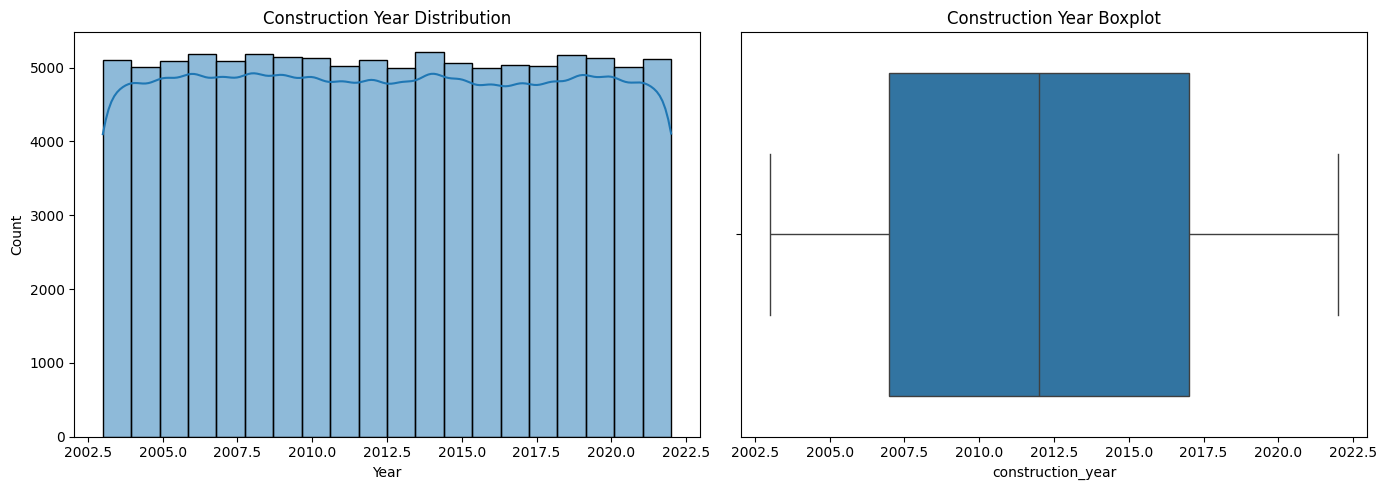

In [1481]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['construction_year'], bins=20, ax=axes[0], kde=True)
axes[0].set_title('Construction Year Distribution')
axes[0].set_xlabel('Year')

sns.boxplot(x=df['construction_year'], ax=axes[1])
axes[1].set_title('Construction Year Boxplot')

plt.tight_layout()
plt.show()

In [1482]:
"""
construction_year has 214 NaNs(~0.2%) 
range from 2003-2022 
the distribution is unifrom 
options:
    - option_1: fill with median year 
    - option_2: drop the rows with missing values
"""

median_year = df["construction_year"].median()
df["construction_year"].fillna(median_year, inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/4234086867.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["construction_year"].fillna(median_year, inplace=True)


In [1483]:
# df = df.dropna(subset=["construction_year"])

Missing values: `price`

`price` contains missing values and requires both type conversion and validation before imputation

- coerce to numeric to handle any non-numeric entries
- check for invalid values (zeros, negatives, suspiciously high prices)
- explore prices by `room_type` and `borough` to understand the distribution and inform the imputation strategy

In [1484]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [1485]:
print(f"Zero prices: {(df["price"] == 0).sum()}")
print(f"Negative prcies: {(df["price"] < 0).sum()}")
print(f"Suspiciously high (>10000): {(df["price"] > 10000).sum()}")

Zero prices: 0
Negative prcies: 0
Suspiciously high (>10000): 0


In [1486]:
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,53282.0,625.190515,331.692782,50.0,340.0,624.0,914.0,1200.0
Hotel room,115.0,666.391304,311.419689,50.0,418.0,643.0,937.5,1193.0
Private room,46183.0,624.955633,331.409189,50.0,340.0,623.0,911.0,1200.0
Shared room,2200.0,634.828182,338.408102,50.0,325.0,651.5,927.0,1199.0


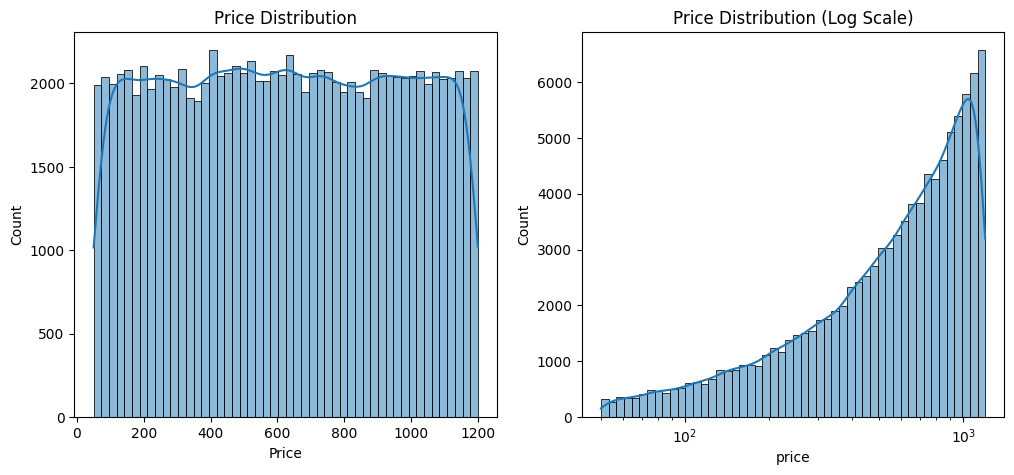

In [1487]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["price"].dropna(), bins=50, ax=axes[0], kde=True)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")


sns.histplot(df['price'].dropna(), bins=50, ax=axes[1], kde=True, log_scale=True)
axes[1].set_title('Price Distribution (Log Scale)')

plt.show()

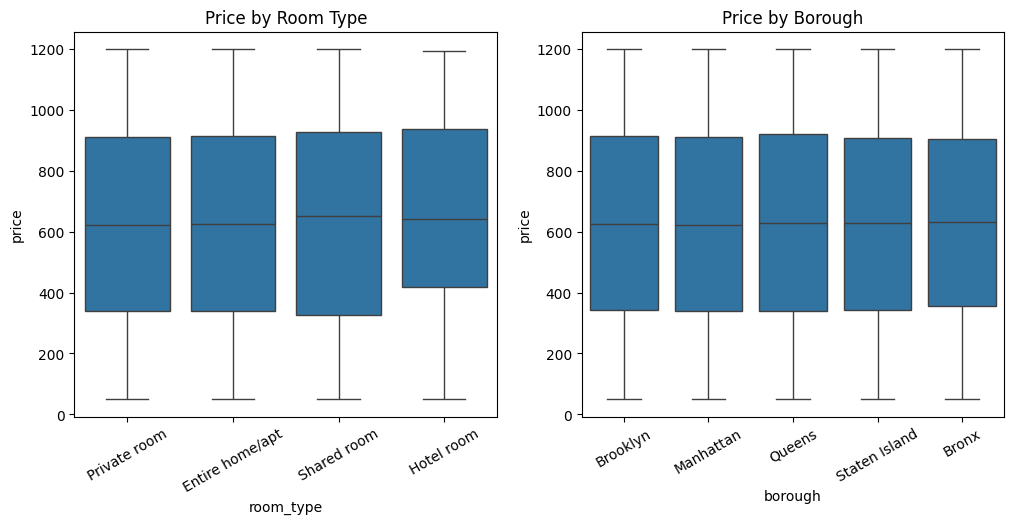

In [1488]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="room_type", y="price", ax=axes[0])
axes[0].set_title("Price by Room Type")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="borough", y="price", ax=axes[1])
axes[1].set_title("Price by Borough")
axes[1].tick_params(axis='x', rotation=30)

In [1489]:
# fill with median price per room_type and borough group
df["price"] = df.groupby(["room_type", "borough"])["price"] \
    .transform(lambda x: x.fillna(x.median()))

In [1490]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                      273
min_nights                       399
review_count                     183
last_review_date               15830
reviews_per_month              15816
review_rating                    319
host_listing_count               319
availability_days_per_year       447
house_rules                    51830
license_number                102024
host_id_length_issue               0
d

Missing values: `service_fee`

- find the service_fee_rate using price column
- fill the missing values with service_fee_rate

In [1491]:
df["service_fee"] = pd.to_numeric(df["service_fee"], errors="coerce")

ratio = df["service_fee"] / df["price"]
ratio.describe()

count    101753.000000
mean          0.199975
std           0.004706
min           0.016051
25%           0.199607
50%           0.200000
75%           0.200389
max           0.383013
dtype: float64

<Axes: ylabel='Count'>

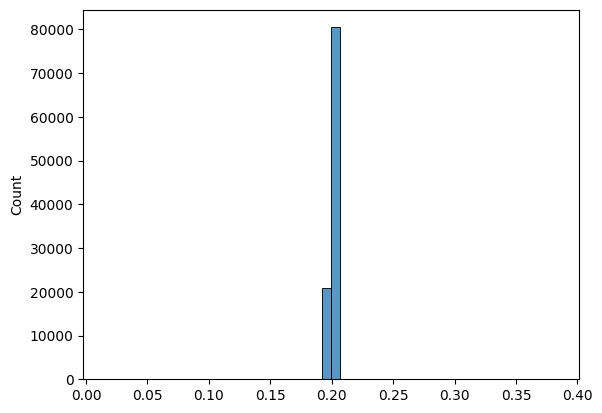

In [1492]:
sns.histplot(ratio, bins=50)

In [1493]:
service_fee_rate = 0.20 

df["service_fee"].fillna(df["price"] * service_fee_rate, inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/634393909.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["service_fee"].fillna(df["price"] * service_fee_rate, inplace=True)


In [1494]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                       399
review_count                     183
last_review_date               15830
reviews_per_month              15816
review_rating                    319
host_listing_count               319
availability_days_per_year       447
house_rules                    51830
license_number                102024
host_id_length_issue               0
d

Missing values: `min_nights`

In [1495]:
df["min_nights"].describe()

count    101627.000000
mean          8.125331
std          30.616201
min       -1223.000000
25%           2.000000
50%           3.000000
75%           5.000000
max        5645.000000
Name: min_nights, dtype: float64

In [1496]:
print(f"Zero values: {(df["min_nights"] == 0).sum()}")
print(f"Negative values: {(df["min_nights"] < 0).sum()}")
print(f"Suspiciously high values (> 365): {(df["min_nights"] > 365).sum()}")

Zero values: 0
Negative values: 13
Suspiciously high values (> 365): 35


<Axes: xlabel='min_nights'>

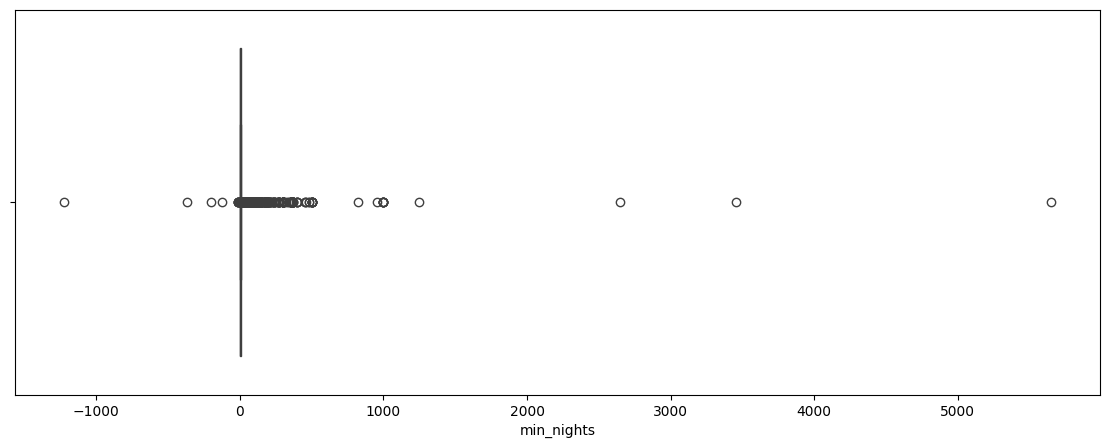

In [1497]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.boxplot(x=df["min_nights"], ax=ax)

In [1498]:
mask = (df["min_nights"] < 0) | (df["min_nights"] > 365) 
count_mask = mask.sum()
print(count_mask)

48


In [1499]:
df = df[(df["min_nights"] >= 0) & (df["min_nights"] <= 365)]

In [1500]:
df["min_nights"].isnull().sum()

np.int64(0)

In [1501]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                         0
review_count                     181
last_review_date               15752
reviews_per_month              15744
review_rating                    298
host_listing_count               319
availability_days_per_year       423
house_rules                    51626
license_number                101577
host_id_length_issue               0
d

Missing values: `review_count`

cross-check - do rows with missing review_count also have missing last_review_date

In [1502]:
missing_reviews = df["review_count"].isna()

print(f"\nMissing review_count AND missing last_review_date: "
      f"{(missing_reviews & df['last_review_date'].isna()).sum()}")
print(f"Missing review_count BUT has last_review_date: "
      f"{(missing_reviews & df['last_review_date'].notna().sum())}")


Missing review_count AND missing last_review_date: 123
Missing review_count BUT has last_review_date: 0         False
1         False
2         False
3         False
4         False
          ...  
102053    False
102054    False
102055    False
102056    False
102057    False
Name: review_count, Length: 101579, dtype: bool


In [1503]:
df["review_count"].fillna(0, inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/3359781122.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["review_count"].fillna(0, inplace=True)


In [1504]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                         0
review_count                       0
last_review_date               15752
reviews_per_month              15744
review_rating                    298
host_listing_count               319
availability_days_per_year       423
house_rules                    51626
license_number                101577
host_id_length_issue               0
d

Missing values: `last_review_date`

In [1505]:
# find the percent of missing values in last_review_date
percent_missing = df["last_review_date"].isnull().sum() / len(df) * 100 
print(f"Percent missing: {percent_missing:.1f}%")

Percent missing: 15.5%


In [1506]:
# identify listings that have last_review_date but review_count is missing 
df["has_review"] = df["last_review_date"].notna().astype(int)

print(df["has_review"].value_counts())
print(f"\nListings that have 0 reviews but has_review=1: "
      f"{((df["review_count"] == 0) & (df["has_review"] == 1)).sum()}")

has_review
1    85827
0    15752
Name: count, dtype: int64

Listings that have 0 reviews but has_review=1: 58


In [1507]:
# identify listings where last_review_date is missing but reviews_per_month is not missing
mask = (df["last_review_date"].isnull()) & (df["reviews_per_month"].notna())
mask.value_counts()

False    101561
True         18
Name: count, dtype: int64

In [1508]:
anomalies = df[mask]
print(anomalies[["review_count", "reviews_per_month", "last_review_date", "review_rating"]].to_string())

       review_count  reviews_per_month last_review_date  review_rating
66            191.0               1.65              NaN            1.0
78             25.0               0.22              NaN            2.0
83             70.0               0.62              NaN            4.0
91             24.0               0.28              NaN            5.0
113            12.0               0.13              NaN            5.0
155            34.0               0.32              NaN            5.0
156           134.0               1.24              NaN            3.0
157            27.0               0.25              NaN            3.0
158           126.0               1.16              NaN            1.0
159            23.0               0.27              NaN            2.0
218           192.0               1.84              NaN            5.0
219            17.0               0.16              NaN            3.0
220           222.0               2.12              NaN            2.0
249   

In [1509]:
# drop rows where last_review_date is missing but reviews_per_month is not missing
df = df[~mask]

In [1510]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                         0
review_count                       0
last_review_date               15734
reviews_per_month              15744
review_rating                    297
host_listing_count               319
availability_days_per_year       416
house_rules                    51620
license_number                101559
host_id_length_issue               0
h

In [1511]:
# identify listings that have last_review_date but review_count is missing 
mask = (df["review_count"] == 0) & (df["has_review"] == 1)
mask.value_counts()

False    101503
True         58
Name: count, dtype: int64

In [1512]:
# drop listings that have last_review_date but review_count is missing 
df = df[~mask]

In [1513]:
# create columns for listings that have no reviews
df["never_reviewed"] = df["last_review_date"].isnull().astype(int)

# fill the missing values of reviews_per_month 
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [1514]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                         0
review_count                       0
last_review_date               15734
reviews_per_month                  0
review_rating                    297
host_listing_count               319
availability_days_per_year       416
house_rules                    51593
license_number                101501
host_id_length_issue               0
h

Missing values: `review_rating`

- find contradictions 

In [1515]:
missing_rating = df['review_rating'].isna()

print(f"\nMissing rating AND has_review=0: "
      f"{(missing_rating & (df['has_review'] == 0)).sum()}")
print(f"Missing rating BUT has_review=1 (contradictions): "
      f"{(missing_rating & (df['has_review'] == 1)).sum()}")


Missing rating AND has_review=0: 36
Missing rating BUT has_review=1 (contradictions): 261


In [1516]:
mask = (missing_rating) & (df['has_review'] == 1)

df = df[~mask]

In [1517]:
df["review_rating"].fillna(0, inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/3125569555.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["review_rating"].fillna(0, inplace=True)


In [1518]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                         0
review_count                       0
last_review_date               15734
reviews_per_month                  0
review_rating                      0
host_listing_count               261
availability_days_per_year       411
house_rules                    51448
license_number                101240
host_id_length_issue               0
h

Missing values: `host_listing_count`

In [1519]:
df["host_id"]

0         80014485718
1         52335172823
2         78829239556
3         85098326012
4         92037596077
             ...     
102053    77326652202
102054    45936254757
102055    23801060917
102056    15593031571
102057    93578954226
Name: host_id, Length: 101242, dtype: int64

In [1520]:
df["listing_id"]

0          1001254
1          1002102
2          1002403
3          1002755
4          1003689
            ...   
102053    57365208
102054    57365760
102055    57366313
102056    57366865
102057    57367417
Name: listing_id, Length: 101242, dtype: int64

In [1521]:
df["host_listing_count"]

0         6.0
1         2.0
2         1.0
3         1.0
4         1.0
         ... 
102053    1.0
102054    2.0
102055    2.0
102056    1.0
102057    1.0
Name: host_listing_count, Length: 101242, dtype: float64

In [1522]:
derived = df.groupby("host_id")["listing_id"].transform("count")

In [1523]:
non_null = df["host_listing_count"].notna()
matches = (df.loc[non_null, "host_listing_count"] == 
           derived[non_null]).sum()
total = non_null.sum()

print(f"Derived matches: {matches}/{total}, ({matches/total*100:.1f}%)")

Derived matches: 62654/100981, (62.0%)


In [1524]:
df["host_listing_count"].fillna(derived, inplace=True)

In [1525]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                         0
review_count                       0
last_review_date               15734
reviews_per_month                  0
review_rating                      0
host_listing_count                 0
availability_days_per_year       411
house_rules                    51448
license_number                101240
host_id_length_issue               0
h

Missing values: `availability_days_per_year`

In [1526]:
df.loc[df['availability_days_per_year'] < 0, 'availability_days_per_year'] = np.nan
df.loc[df['availability_days_per_year'] > 365, 'availability_days_per_year'] = np.nan

In [1527]:
df['availability_days_per_year'] = (
    df.groupby(['room_type', 'borough'])['availability_days_per_year']
    .transform(lambda x: x.fillna(x.median()))
)

In [1528]:
df.isnull().sum()

listing_id                         0
listing_name                       0
host_id                            0
host_identity_verified             0
host_name                          0
borough                            0
neighbourhood                      0
latitude                           0
longitude                          0
country                            0
country_code                       0
instant_bookable                   0
cancellation_policy                0
room_type                          0
construction_year                  0
price                              0
service_fee                        0
min_nights                         0
review_count                       0
last_review_date               15734
reviews_per_month                  0
review_rating                      0
host_listing_count                 0
availability_days_per_year         0
house_rules                    51448
license_number                101240
host_id_length_issue               0
h

Missing values: `house_rules`

In [1529]:
df["house_rules"].fillna("Not mentioned", inplace=True)

/var/folders/h9/b2tnx71j6h7__t4jlxrs4ccw0000gn/T/ipykernel_1868/2554363871.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["house_rules"].fillna("Not mentioned", inplace=True)


Missing values: `license_number`

In [1530]:
df["license_number"].isnull().sum()

np.int64(101240)

In [1531]:
pct_null = df["license_number"].isnull().sum() / len(df) * 100
print(f"{pct_null}%")

99.99802453527192%


In [1532]:
df.drop(columns=["license_number"], axis=1, inplace=True)

In [1533]:
df.isnull().sum()

listing_id                        0
listing_name                      0
host_id                           0
host_identity_verified            0
host_name                         0
borough                           0
neighbourhood                     0
latitude                          0
longitude                         0
country                           0
country_code                      0
instant_bookable                  0
cancellation_policy               0
room_type                         0
construction_year                 0
price                             0
service_fee                       0
min_nights                        0
review_count                      0
last_review_date              15734
reviews_per_month                 0
review_rating                     0
host_listing_count                0
availability_days_per_year        0
house_rules                       0
host_id_length_issue              0
has_review                        0
never_reviewed              

### Fix the data types

In [1534]:
df.dtypes

listing_id                      int64
listing_name                   object
host_id                         int64
host_identity_verified         object
host_name                      object
borough                        object
neighbourhood                  object
latitude                      float64
longitude                     float64
country                        object
country_code                   object
instant_bookable               object
cancellation_policy            object
room_type                      object
construction_year             float64
price                         float64
service_fee                   float64
min_nights                    float64
review_count                  float64
last_review_date               object
reviews_per_month             float64
review_rating                 float64
host_listing_count            float64
availability_days_per_year    float64
house_rules                    object
host_id_length_issue             bool
has_review  

In [1535]:
df["instant_bookable"].unique()

array([False, True], dtype=object)

In [1536]:
df["instant_bookable"] = df["instant_bookable"].astype(bool)

In [1537]:
int_columns = ["construction_year", "min_nights", "review_count", "host_listing_count", "availability_days_per_year"] 

In [1538]:
df[int_columns].describe()

,construction_year,min_nights,review_count,host_listing_count,availability_days_per_year
count,101242.000000,101242.000000,101242.000000,101242.000000,101242.000000
mean,2012.486616,7.847544,27.373027,7.921801,132.935338
std,5.759106,17.041467,49.307659,32.218150,127.805882
min,2003.000000,1.000000,0.000000,1.000000,0.000000
25%,2008.000000,2.000000,1.000000,1.000000,4.000000
50%,2012.000000,3.000000,7.000000,1.000000,90.000000
75%,2017.000000,5.000000,30.000000,2.000000,248.000000
max,2022.000000,365.000000,1024.000000,332.000000,365.000000


In [1539]:
for col in int_columns:
    mask = df[col].notna() & (df[col] != df[col].astype(int))
    
    if mask.any():
        print(f"\nProblem column: {col}")
        print(df.loc[mask, col].head(10))
        print(f"Count: {mask.sum()}")


Problem column: availability_days_per_year
2676     164.5
3705     164.5
3919     164.5
8336     164.5
11469    164.5
11542    164.5
11563    164.5
17053    164.5
48710    164.5
48712    164.5
Name: availability_days_per_year, dtype: float64
Count: 17


In [1540]:
for col in int_columns:
    mask = df[col].notna() & (df[col] % 1 != 0)

    if mask.any():
        print(f"Removing rows from column: {col}")
        df = df[~mask]

Removing rows from column: availability_days_per_year


In [1541]:
df[int_columns] = df[int_columns].astype('Int64')

In [1542]:
df.dtypes

listing_id                      int64
listing_name                   object
host_id                         int64
host_identity_verified         object
host_name                      object
borough                        object
neighbourhood                  object
latitude                      float64
longitude                     float64
country                        object
country_code                   object
instant_bookable                 bool
cancellation_policy            object
room_type                      object
construction_year               Int64
price                         float64
service_fee                   float64
min_nights                      Int64
review_count                    Int64
last_review_date               object
reviews_per_month             float64
review_rating                 float64
host_listing_count              Int64
availability_days_per_year      Int64
house_rules                    object
host_id_length_issue             bool
has_review  

In [1543]:
df["last_review_date"]

0         10/19/2021
1          5/21/2022
2                NaN
3           7/5/2019
4         11/19/2018
             ...    
102053     3/27/2019
102054     8/31/2017
102055     6/26/2019
102056           NaN
102057     6/15/2019
Name: last_review_date, Length: 101225, dtype: object

In [1544]:
df["last_review_date"] = pd.to_datetime(df["last_review_date"], format="%m/%d/%Y", errors="coerce")

In [1545]:
df.dtypes

listing_id                             int64
listing_name                          object
host_id                                int64
host_identity_verified                object
host_name                             object
borough                               object
neighbourhood                         object
latitude                             float64
longitude                            float64
country                               object
country_code                          object
instant_bookable                        bool
cancellation_policy                   object
room_type                             object
construction_year                      Int64
price                                float64
service_fee                          float64
min_nights                             Int64
review_count                           Int64
last_review_date              datetime64[ns]
reviews_per_month                    float64
review_rating                        float64
host_listi

In [1546]:
df.sample(40)

,listing_id,listing_name,host_id,host_identity_verified,host_name,borough,neighbourhood,latitude,longitude,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,min_nights,review_count,last_review_date,reviews_per_month,review_rating,host_listing_count,availability_days_per_year,house_rules,host_id_length_issue,has_review,never_reviewed
70672,40033482,1 Guest Room In New Condo,25117803797,not_verified,Marisa,Brooklyn,Brooklyn Heights,40.701170,-73.991470,United States,US,True,moderate,Private room,2012,884.0,177.0,1,3,2015-10-01,0.05,3.0,1,0,Not mentioned,False,1,0
90868,51187732,Great 1 Bedroom Apartment,69967686013,verified,Vasili,Manhattan,Washington Heights,40.853100,-73.938720,United States,US,False,flexible,Entire home/apt,2016,119.0,24.0,2,0,NaT,0.00,5.0,1,0,No smoking or pets allowed and we request that...,False,0,1
63732,36200520,Modern New Renovation Room,40808686203,verified,Kristina & Vlada,Brooklyn,Bedford-Stuyvesant,40.688440,-73.942410,United States,US,True,flexible,Private room,2020,1102.0,220.0,30,2,2021-09-22,0.14,2.0,1,365,Not mentioned,False,1,0
32126,18744526,*New-Luxury Heart Of Midwest Step Away From Ti...,55869043259,not_verified,Lindsey,Manhattan,Hell's Kitchen,40.760970,-73.999590,United States,US,False,moderate,Entire home/apt,2017,107.0,21.0,4,38,2019-06-24,2.79,3.0,1,159,House Rules 1. Check-in is 4 pm local time. If...,False,1,0
99831,56137997,Fantastic Master Bedroom,55783816997,verified,Ryan,Brooklyn,Prospect-Lefferts Gardens,40.656780,-73.951540,United States,US,False,flexible,Private room,2011,675.0,135.0,2,5,2019-03-24,0.16,2.0,1,364,Not mentioned,False,1,0
21645,12955870,Cabins At Chelsea (Nyc),10877984270,not_verified,Maria,Manhattan,Chelsea,40.748190,-73.995400,United States,US,False,moderate,Private room,2020,346.0,69.0,1,147,2019-06-23,5.08,2.0,5,292,Not mentioned,False,1,0
87416,49281193,Spacious Room In Historic Part Of Manhattan,54632875128,not_verified,Helen,Manhattan,Harlem,40.829840,-73.942260,United States,US,True,strict,Private room,2011,205.0,41.0,2,57,2019-07-04,1.57,5.0,1,287,Must be clean and respectful. if you come back...,False,1,0
1582,1875075,Bright 1 Br In Brooklyn,61881063152,not_verified,Silvia,Brooklyn,Crown Heights,40.674730,-73.962630,United States,US,False,strict,Entire home/apt,2009,239.0,48.0,3,12,2019-03-17,0.18,4.0,1,362,Not mentioned,False,1,0
48016,27520573,Charming And Spacious 2 Bedroom Midtown Apt,77652206129,not_verified,Axay,Manhattan,Hell's Kitchen,40.764960,-73.989280,United States,US,True,flexible,Entire home/apt,2004,511.0,102.0,3,0,NaT,0.00,3.0,1,167,- Please treat this home as your own and respe...,False,0,1
95901,53967458,Relaxing And Tranquil Room In Park Slope,96238252079,not_verified,Jenn,Brooklyn,South Slope,40.661100,-73.981090,United States,US,True,flexible,Private room,2021,1162.0,232.0,1,5,2018-11-14,0.39,3.0,2,0,Not mentioned,False,1,0


handle #NAME? in `house_rules`

The `house_rules` column contains `#NAME?` values — Excel formula 
error introduced during export 

In [ ]:
# find the number of rows with #NAME? 
mask = df['house_rules'] == '#NAME?'
count_mask = mask.sum()
print(count_mask)

2682


In [ ]:
# replace Excel artefact '#NAME?' with 'Not mentioned' — consistent with rows where hosts intentionally left house rules blank
df['house_rules'] = df['house_rules'].replace('#NAME?', pd.NA).fillna('Not mentioned')

In [1556]:
# confirm no '#NAME?' values remain after replacement
assert (df['house_rules'] == '#NAME?').sum() == 0, \
    "Replacement incomplete — '#NAME?' values still present"
print("Replacement verified.")

Replacement verified.


In [1557]:
df.to_csv("clean_airbnb_data.csv", index=False)